In [2]:
import pickle
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2
from Dataset import MMLUDataset
from itertools import product
from itertools import combinations
from collections import defaultdict, Counter
import random

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
%matplotlib inline

import yaml
from typing import List, Dict, Callable
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/uufs/chpc.utah.edu/common/home/u0879092/software/pkg/miniconda3/envs/opend5new/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Error ratio and coverage using subject meta labels from MMLU
Below we analyze predictions of GPT-3.5-Turbo on MMLU released by Mozannar et al., 2023 to analyze if meta-labels can be used a proxies for failure patterns of this model.

First lets just look at the subset of MMLU which covers math problems

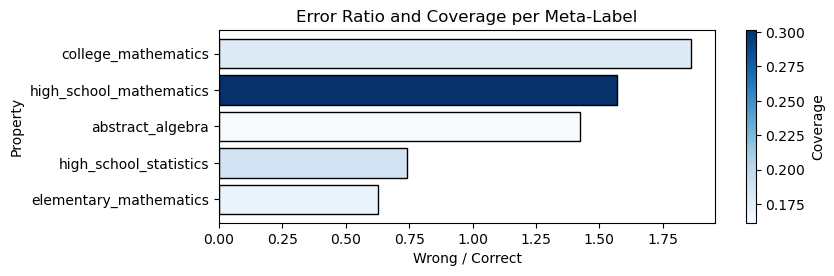

In [3]:
mmlu_math = MMLUDataset('mmlu-math-reg').data
df = calculate_error_metrics(mmlu_math, 'subject', 'ai_correct', mmlu=True)
qm = df_to_dict(df, 'subject')
plot_metrics(qm)

Now another subset - MMLU-Health

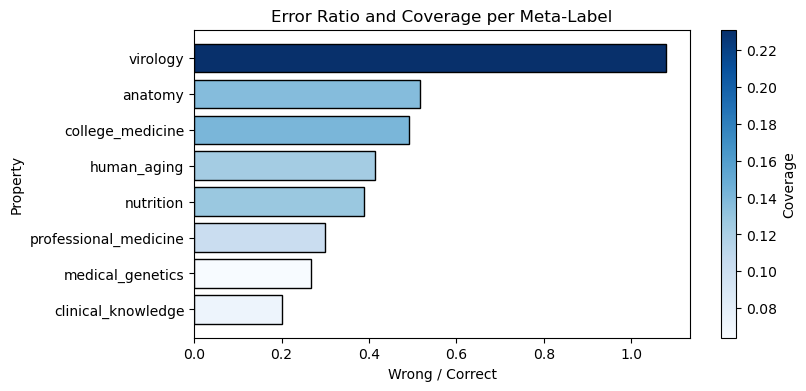

In [4]:
mmlu_health = MMLUDataset('mmlu-health-reg').data
df = calculate_error_metrics(mmlu_health, 'subject', 'ai_correct', mmlu=True)
qm = df_to_dict(df, 'subject')
plot_metrics(qm)

MMLU has a number of other subcategories we can examine as well

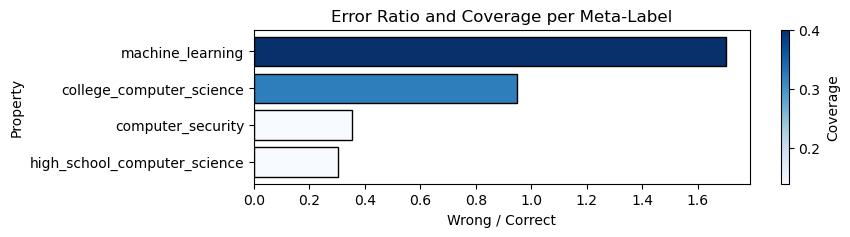

In [5]:
sc = 'computer science' # politics, physics, culture, computer science
mmlu_data = MMLUDataset('mmlu')
mmlu_data.choose_subcat_mmlu(subcat=sc)
mmlu_data = mmlu_data.data
df = calculate_error_metrics(mmlu_data, 'subject', 'ai_correct', mmlu=True)
qm = df_to_dict(df, 'subject')
plot_metrics(qm)

Taking a global perspective, we can compare error ratio and coverage of each subject with respect to all subjects in the datase.
Here we can see there are many properties with high error ratio. But they are spread across a large number of subjects. In fact, we'd need 17 properties to cover just 50% of all of the errors. This illustrates a case of high-cognitive burden if we were to teach people to identify all of these subjects.

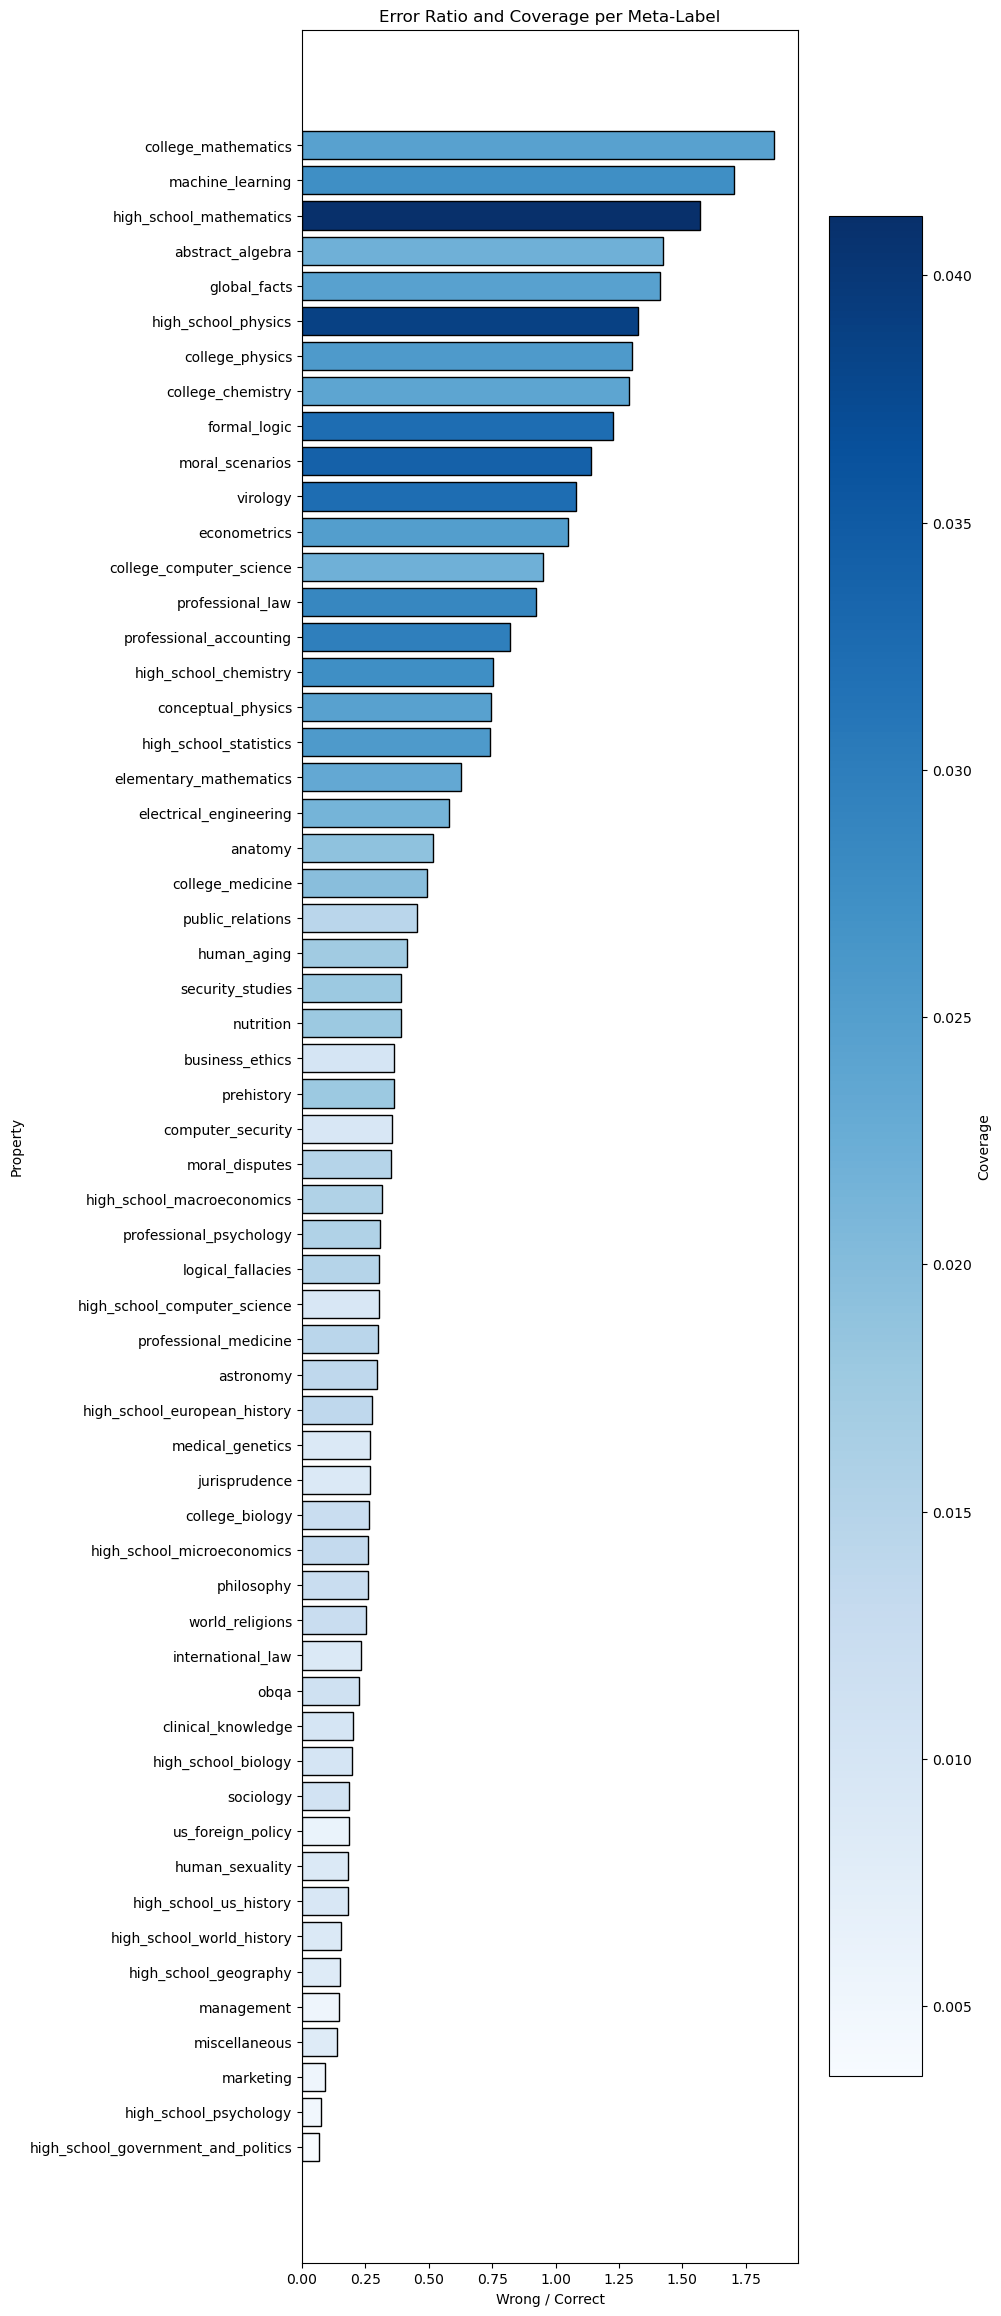

In [6]:
mmlu_data = MMLUDataset('mmlu').data
df = calculate_error_metrics(mmlu_data, 'subject', 'ai_correct', mmlu=True)
qm = df_to_dict(df, 'subject')
plot_metrics(qm)

Another option is to look the distribution of errors the sub-category level instead of subjects. This provides a view at a coarser granularity.

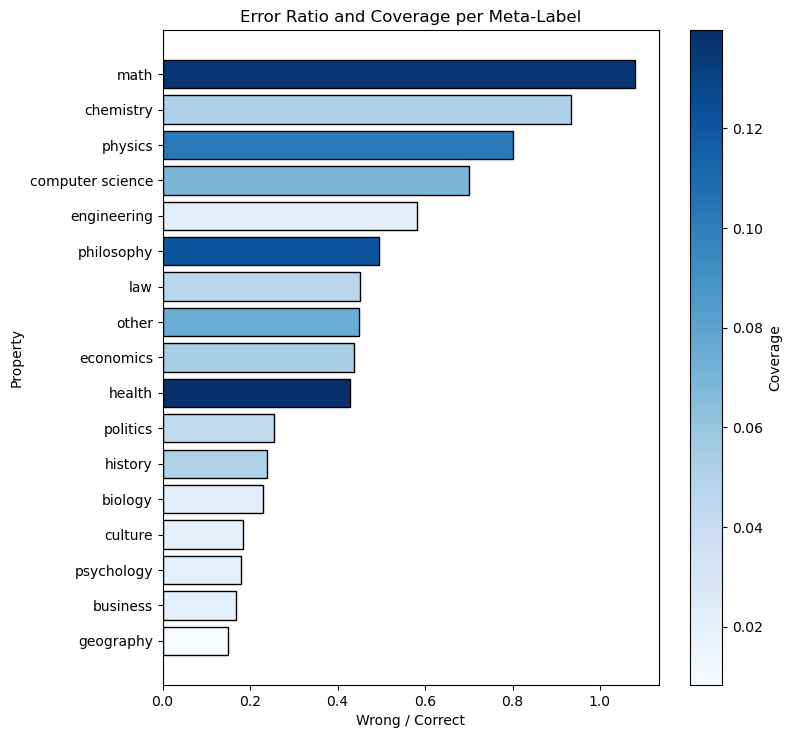

In [7]:
mmlu_subcats = MMLUDataset('mmlu').data
df = calculate_error_metrics(mmlu_data, 'subcat', 'ai_correct', mmlu=True)
qm = df_to_dict(df, 'subcat')
plot_metrics(qm)


We can also filter to just a few sub-categories of interest

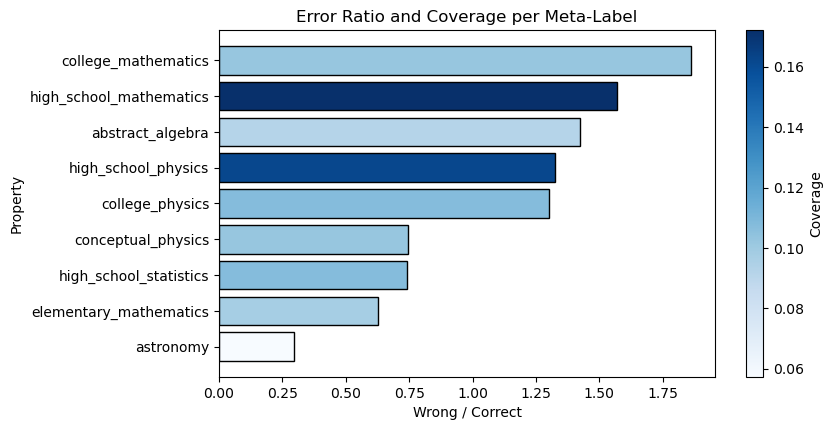

In [8]:
mmlu_data = MMLUDataset('mmlu').data
subcats = ['psyhology', 'physics', 'math']
mmlu_data = mmlu_data[mmlu_data['subcat'].isin(subcats)]
df = calculate_error_metrics(mmlu_data, 'subject', 'ai_correct', mmlu=True)
qm = df_to_dict(df, 'subject')
plot_metrics(qm)

### MMLU Figure Creation
The code below is used to create a single figure showing the landscape for each sub-category individually (Fig. 10 in Appendix of paper)

MMLU Failure Patterns Figure - Vertical

/tmp/ipykernel_3871726/3483010853.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')


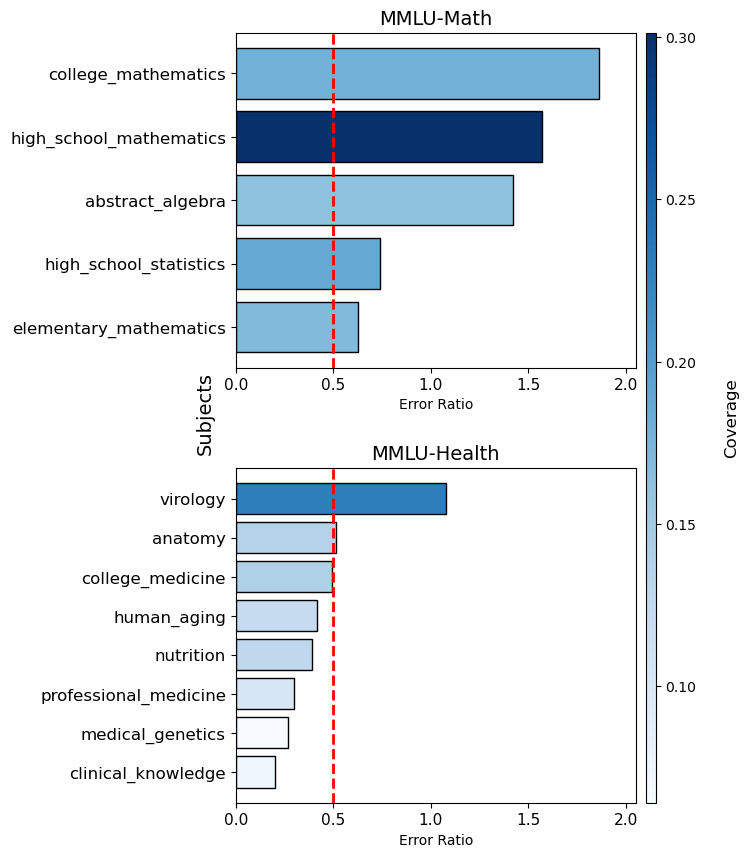

In [9]:
mmlu_math_data = MMLUDataset('mmlu-math-reg').data
mmlu_health_data = MMLUDataset('mmlu-health-reg').data

# # Two vertical subplots
fig, axes = plt.subplots(2, 1, figsize=(5, 10), constrained_layout=False)

df1 = calculate_error_metrics(mmlu_math_data, 'subject', 'ai_correct', mmlu=True)
df2 = calculate_error_metrics(mmlu_health_data, 'subject', 'ai_correct', mmlu=True)

qm1 = df_to_dict(df1, 'subject')
qm2 = df_to_dict(df2, 'subject')



fig_data = [qm1, qm2]
plot_names = ['MMLU-Math', 'MMLU-Health']

# Determine global colormap scale (across all datasets)
all_coverages = np.concatenate([
    np.array([item['coverage'] for item in data.values()]) for data in fig_data
])
norm = mcolors.Normalize(vmin=min(all_coverages), vmax=max(all_coverages))
cmap = cm.get_cmap('Blues')

# Determine global x-axis limits
all_wrong_vs_correct = np.concatenate([
    np.array([item['wrongVScorrect'] for item in data.values()]) for data in fig_data
])
xlim = (0, max(all_wrong_vs_correct) * 1.1)

# Plot each dataset
for ax, data, title in zip(axes, fig_data, plot_names):
    plot_metrics_fig(data, ax, title, norm, cmap, xlim)

# Shared y-axis label
fig.text(0.04, 0.5, 'Subjects', ha='center', va='center', rotation='vertical', fontsize=14)

# Adjust layout for spacing
plt.subplots_adjust(left=0.1, right=0.9, hspace=0.3)

# --- Dynamically align colorbar with both subplots ---
fig.canvas.draw()  # must draw before getting positions

# Get combined bounding box of all subplots (in figure coordinates)
bbox0 = axes[0].get_position()
bbox1 = axes[1].get_position()
bottom = bbox1.y0
top = bbox0.y1
left = bbox0.x1 + 0.02  # small padding to the right of the plots

# Add colorbar using that exact vertical span
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([left, bottom, 0.02, top - bottom])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Coverage', fontsize=12, labelpad=20)

# plt.savefig('figs/{fig_name}')

Horizontal Figure

/tmp/ipykernel_3871726/744362662.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')
/tmp/ipykernel_3871726/744362662.py:31: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.05)  # Adjust the left side to provide space for the y-label


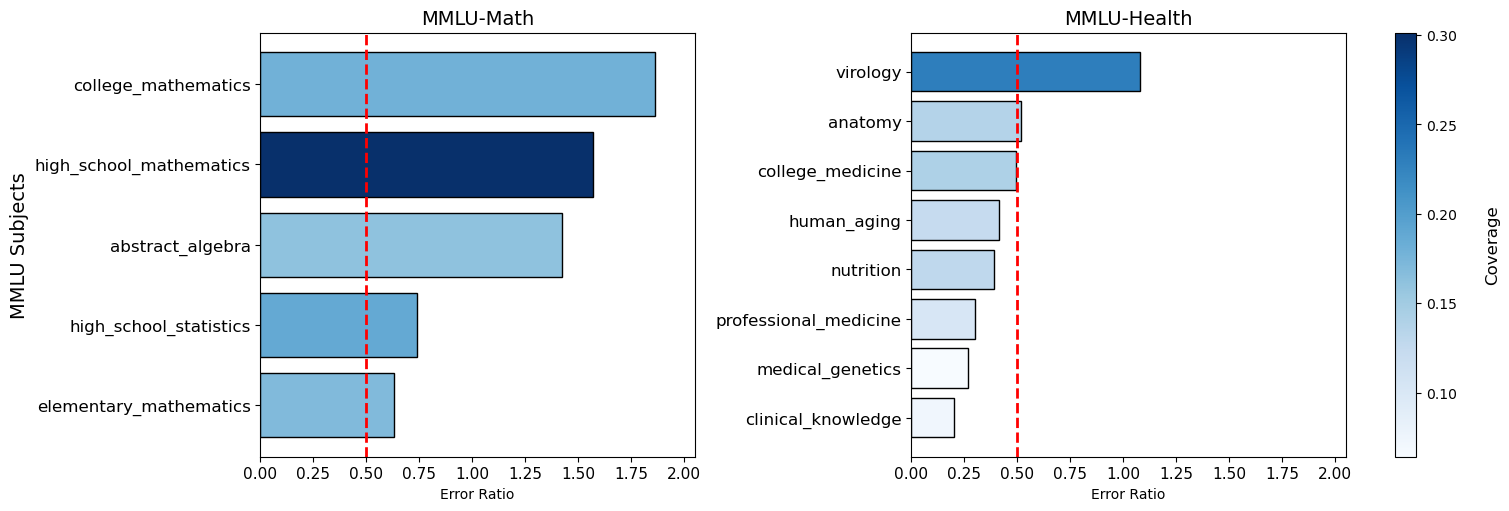

In [10]:
mmlu_math_data = MMLUDataset('mmlu-math-reg').data
mmlu_health_data = MMLUDataset('mmlu-health-reg').data
# Example usage with multiple subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

df1 = calculate_error_metrics(mmlu_math_data, 'subject', 'ai_correct', mmlu=True)
df2 = calculate_error_metrics(mmlu_health_data, 'subject', 'ai_correct', mmlu=True)

qm1 = df_to_dict(df1, 'subject')
qm2 = df_to_dict(df2, 'subject')

fig_data = [qm1, qm2]
plot_names = ['MMLU-Math', 'MMLU-Health']

# Determine global colormap scale (across all datasets)
all_coverages = np.concatenate([np.array([item['coverage'] for item in data.values()]) for data in fig_data])
norm = mcolors.Normalize(vmin=min(all_coverages), vmax=max(all_coverages))
cmap = cm.get_cmap('Blues')

# Determine global x-axis limits
all_wrong_vs_correct = np.concatenate([np.array([item['wrongVScorrect'] for item in data.values()]) for data in fig_data])
xlim = (0, max(all_wrong_vs_correct) * 1.1)  # Add 10% padding for better visualization

# Add a shared y-axis label for all subplots
# fig.text(0.04, 0.5, 'MathCAMPS Standard', ha='center', va='center', rotation='vertical', fontsize=14)

# Add individual y-axis label for the left-most subplot
axes[0].set_ylabel('MMLU Subjects', fontsize=14)

# Adjust layout to provide space for the shared y-axis label
plt.subplots_adjust(left=0.05)  # Adjust the left side to provide space for the y-label
# Generate subplots
for ax, data, title in zip(axes, fig_data, plot_names):
    plot_metrics_fig(data, ax, title, norm, cmap, xlim)

# Add a single shared colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed for the colorbar
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
# cbar.set_label('Coverage', fontsize=12, rotation=270, labelpad=20)
cbar.set_label('Coverage', fontsize=12, labelpad=20)

# plt.savefig('figs/{fig_name}')


subcats= ['psychology', 'politics', 'physics', 'philosophy', 'history', 'other', 'law', 'economics', 'culture', 'computer science', 'business', 'geography', 'chemistry', 'engineering', 'biology']


/tmp/ipykernel_3871726/206983488.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')


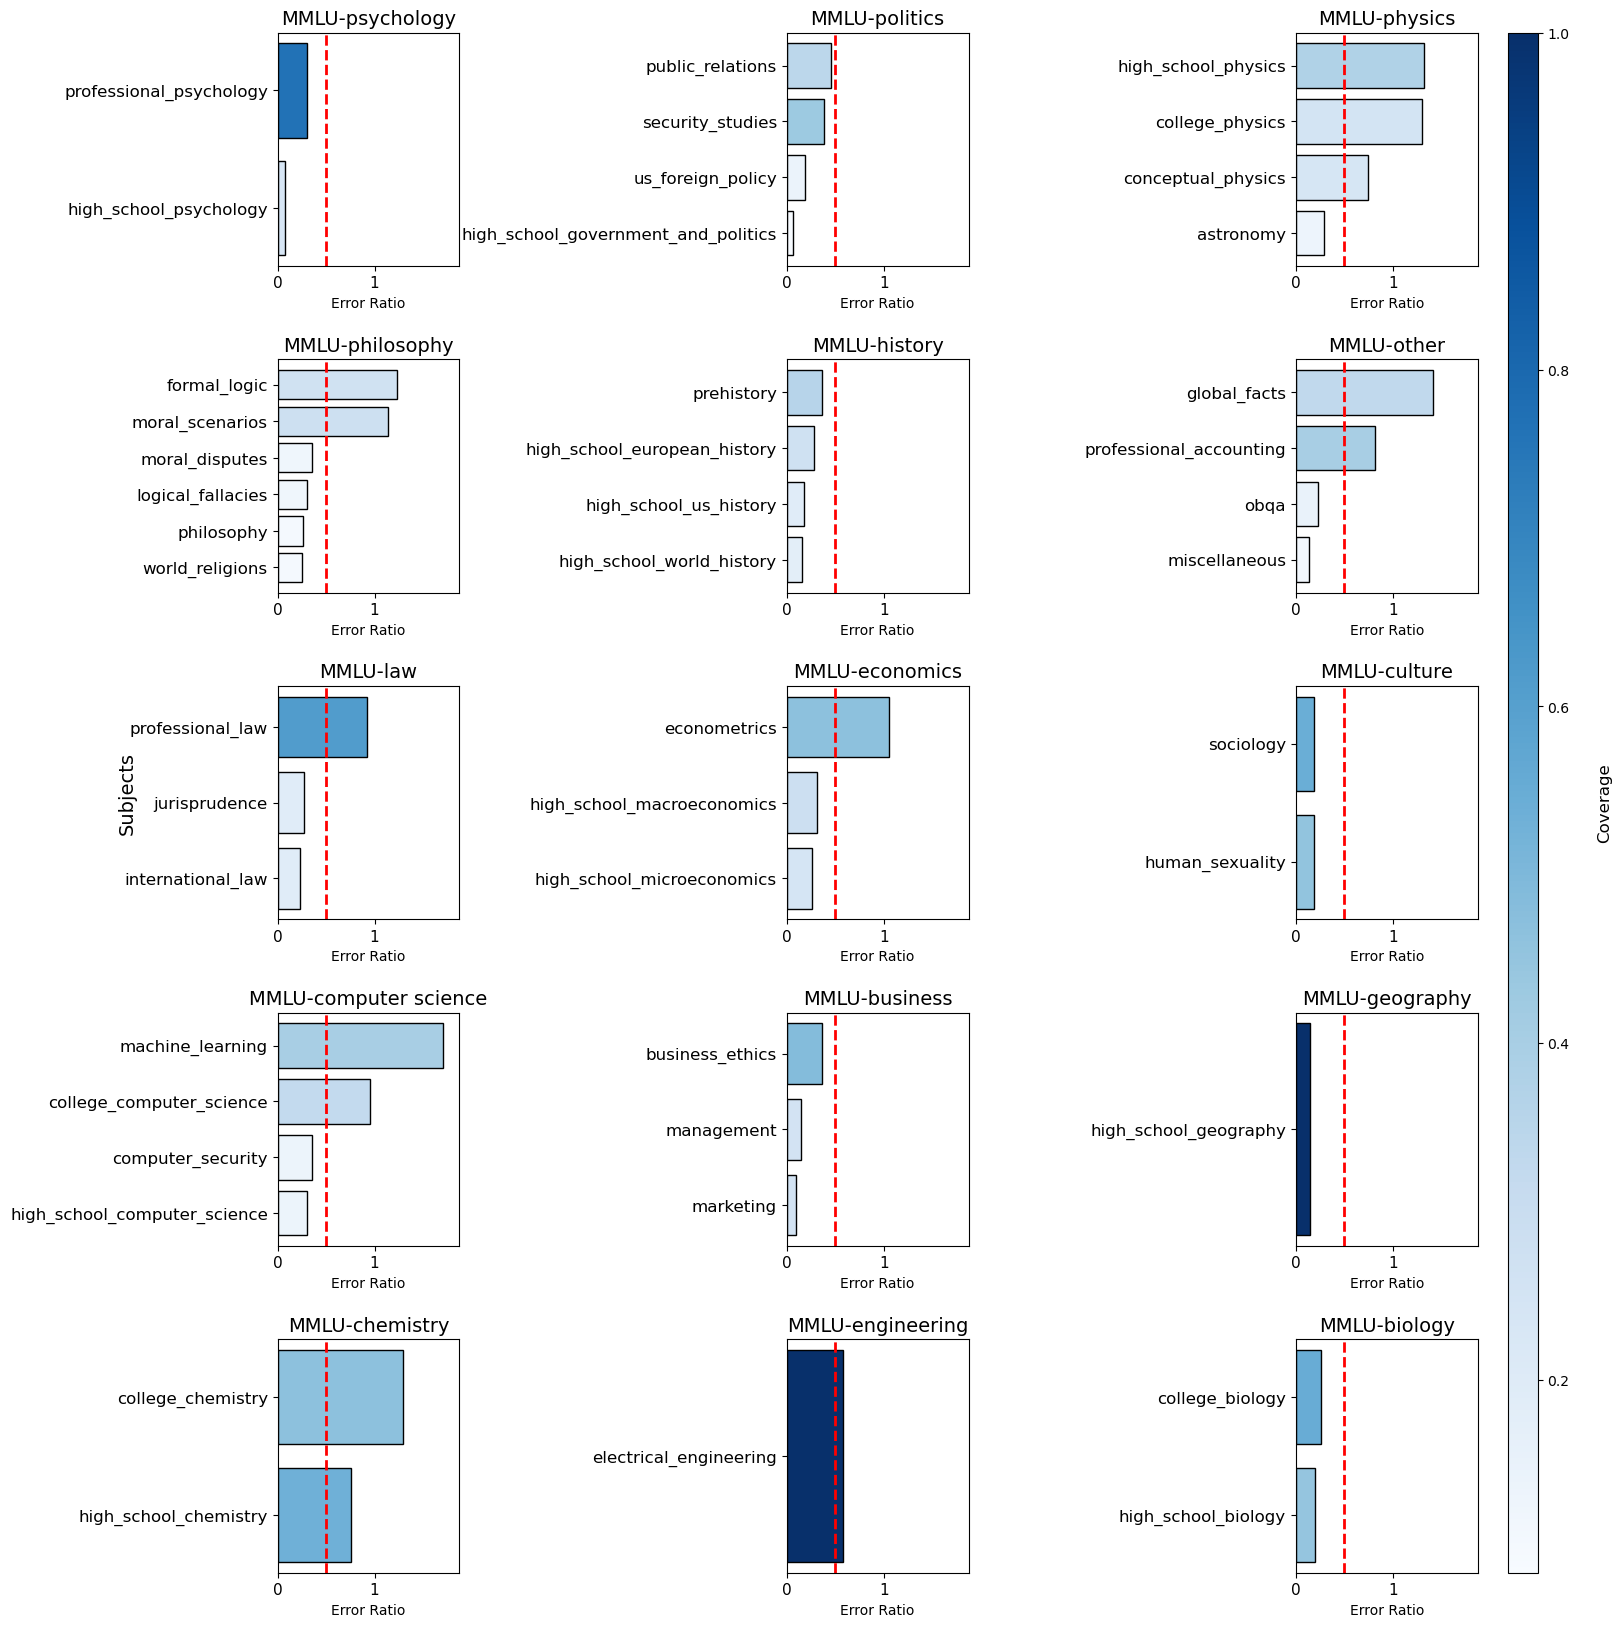

In [11]:
mmlu_data = MMLUDataset('mmlu')
subcats = mmlu_data.data.subcat.unique()
# remove math and health from this plot
subcats = [s for s in subcats if s not in ['math', 'health']]
qms = []
print("subcats=", subcats)
for subcat in subcats:
    mmlu_data = MMLUDataset('mmlu')
    mmlu_data.choose_subcat_mmlu(subcat=subcat)
    d = mmlu_data.data
    df = calculate_error_metrics(d, 'subject', 'ai_correct', mmlu=True)
    q = df_to_dict(df, 'subject')
    # q = QualityMetricsGold(d, 'subject').metrics
    # print(q)
    qms.append(q)

# Example:
plot_names = [f'MMLU-{subcat}' for subcat in subcats]


num_plots = len(qms)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig_width = 15  # slightly wider
fig_height = 4 * nrows
fig, axes = plt.subplots(
    nrows, ncols, figsize=(fig_width, fig_height), constrained_layout=False
)

# Flatten axes array for iteration
axes = np.ravel(axes)

# --- Shared normalization and limits ---
all_coverages = np.concatenate([
    np.array([item['coverage'] for item in data.values()]) for data in qms
])
norm = mcolors.Normalize(vmin=np.min(all_coverages), vmax=np.max(all_coverages))
cmap = cm.get_cmap('Blues')

all_wrong_vs_correct = np.concatenate([
    np.array([item['wrongVScorrect'] for item in data.values()]) for data in qms
])
xlim = (0, np.max(all_wrong_vs_correct) * 1.1)

# --- Plot each dataset ---
for ax, data, title in zip(axes, qms, plot_names):
    plot_metrics_fig(data, ax, title, norm, cmap, xlim)

# Turn off any unused axes
for ax in axes[len(qms):]:
    ax.axis("off")

# Shared y-axis label
fig.text(0, 0.5, 'Subjects', ha='center', va='center', rotation='vertical', fontsize=14)

# --- Adjust spacing for two-column layout ---
plt.subplots_adjust(
    left=0.1,   # room for shared y-label
    right=0.9,  # room for colorbar
    hspace=0.4, # vertical space
    wspace=1.8 # increased horizontal space to prevent overlap
)


# --- Shared colorbar aligned with all visible subplots ---
fig.canvas.draw()

bboxes = [ax.get_position() for ax in axes if ax.get_visible()]
bottom = min(b.y0 for b in bboxes)
top = max(b.y1 for b in bboxes)
left = max(b.x1 for b in bboxes) + 0.02

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([left, bottom, 0.02, top - bottom])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Coverage', fontsize=12, labelpad=20)

# plt.show()
# plt.savefig('figs/{name_fig}', dpi=300, bbox_inches='tight', pad_inches=0.05)

### MathCAMPS
Topic metadata is commonly found in datasets, but in some cases we might have other kinds of meta-labels.
Here we look at a dataset which maps educational standards for math curricula to problem instances.
We repeat the same analysis, but now the properties are "math standards"

### MathCAMPS Figure Creation

In [12]:
mathcamps_gpt4 = load_mathcamps_data('datasets/mathcamps/model-responses/v1/openai.json', 'gpt-4o-2024-05-13')
mathcamps_claude_sonnet = load_mathcamps_data('datasets/mathcamps/model-responses/v1/anthropic.json', 'claude-3-sonnet-20240229')
mathcamps_gpt35_turbo = load_mathcamps_data('datasets/mathcamps/model-responses/v1/openai.json', 'gpt-3.5-turbo-0125')
mathcamps_claude_opus = load_mathcamps_data('datasets/mathcamps/model-responses/v1/anthropic.json', 'claude-3-opus-20240229')
mathcamps_claude_haiku = load_mathcamps_data('datasets/mathcamps/model-responses/v1/anthropic.json', 'claude-3-haiku-20240307')

Plot error ratio and coverage figure for MathCAMPS standards for 3 models. (Fig 3 in paper)

/tmp/ipykernel_3871726/699027782.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')
/tmp/ipykernel_3871726/699027782.py:30: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.05)  # Adjust the left side to provide space for the y-label


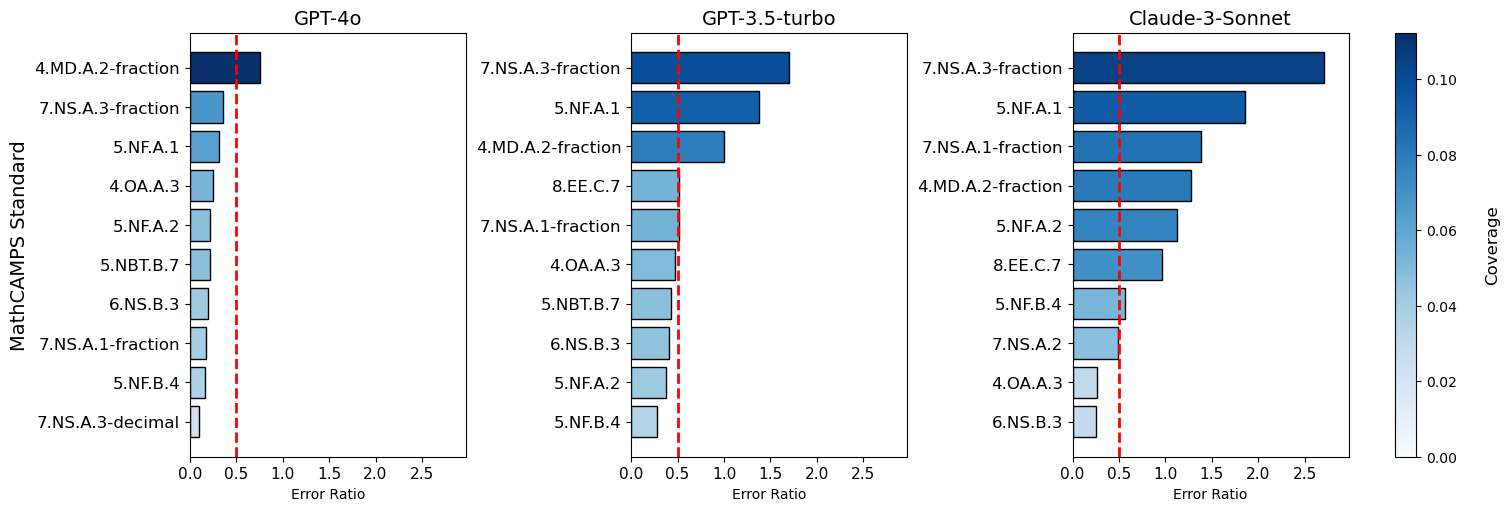

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
# convert 
df1 = calculate_error_metrics(mathcamps_gpt4, 'standard', 'correct')
df2 = calculate_error_metrics(mathcamps_gpt35_turbo, 'standard', 'correct')
df3 = calculate_error_metrics(mathcamps_claude_sonnet, 'standard', 'correct')

qm1 = df_to_dict(df1, 'standard')
qm2 = df_to_dict(df2, 'standard')
qm3 = df_to_dict(df3, 'standard')
del qm1['8.EE.C.8']
del qm2['8.EE.C.8']
del qm3['8.EE.C.8']

fig_data = [qm1, qm2, qm3]
plot_names = ['GPT-4o', 'GPT-3.5-turbo', 'Claude-3-Sonnet']

# Determine global colormap scale (across all datasets)
all_coverages = np.concatenate([np.array([item['coverage'] for item in data.values()]) for data in fig_data])
norm = mcolors.Normalize(vmin=min(all_coverages), vmax=max(all_coverages))
cmap = cm.get_cmap('Blues')

# Determine global x-axis limits
all_wrong_vs_correct = np.concatenate([np.array([item['wrongVScorrect'] for item in data.values()]) for data in fig_data])
xlim = (0, max(all_wrong_vs_correct) * 1.1)  # Add 10% padding for better visualization

# Add individual y-axis label for the left-most subplot
axes[0].set_ylabel('MathCAMPS Standard', fontsize=14)

# Adjust layout to provide space for the shared y-axis label
plt.subplots_adjust(left=0.05)  # Adjust the left side to provide space for the y-label
# Generate subplots
for ax, data, title in zip(axes, fig_data, plot_names):
    plot_metrics_fig_mathcamps(data, ax, title, norm, cmap, xlim)

# Add a single shared colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed for the colorbar
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
# cbar.set_label('Coverage', fontsize=12, rotation=270, labelpad=20)
cbar.set_label('Coverage', fontsize=12, labelpad=20)

# plt.savefig('figs/{fig_name}')


Plotting a figure with Sonnet, Opus, and Haiku

/tmp/ipykernel_3871726/1560052787.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')
/tmp/ipykernel_3871726/1560052787.py:30: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.05)  # Adjust the left side to provide space for the y-label


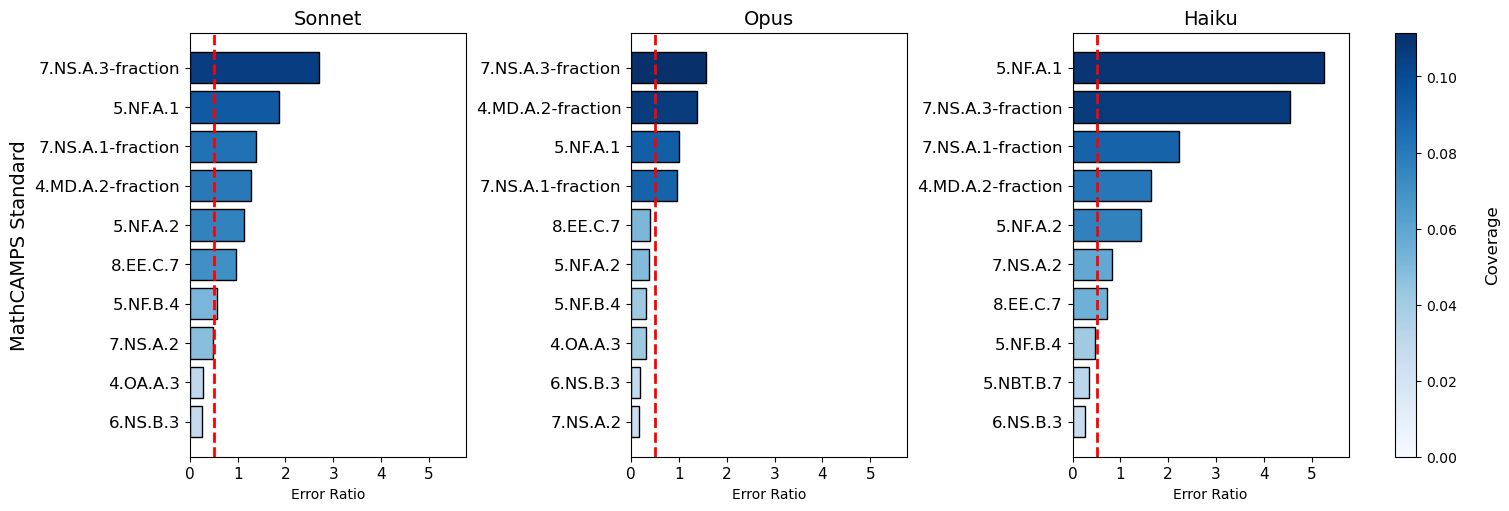

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
# convert 
df1 = calculate_error_metrics(mathcamps_claude_sonnet, 'standard', 'correct')
df2 = calculate_error_metrics(mathcamps_claude_opus, 'standard', 'correct')
df3 = calculate_error_metrics(mathcamps_claude_haiku, 'standard', 'correct')

qm1 = df_to_dict(df1, 'standard')
qm2 = df_to_dict(df2, 'standard')
qm3 = df_to_dict(df3, 'standard')
del qm1['8.EE.C.8']
del qm2['8.EE.C.8']
del qm3['8.EE.C.8']

fig_data = [qm1, qm2, qm3]
plot_names = ['Sonnet', 'Opus', 'Haiku']

# Determine global colormap scale (across all datasets)
all_coverages = np.concatenate([np.array([item['coverage'] for item in data.values()]) for data in fig_data])
norm = mcolors.Normalize(vmin=min(all_coverages), vmax=max(all_coverages))
cmap = cm.get_cmap('Blues')

# Determine global x-axis limits
all_wrong_vs_correct = np.concatenate([np.array([item['wrongVScorrect'] for item in data.values()]) for data in fig_data])
xlim = (0, max(all_wrong_vs_correct) * 1.1)  # Add 10% padding for better visualization

# Add individual y-axis label for the left-most subplot
axes[0].set_ylabel('MathCAMPS Standard', fontsize=14)

# Adjust layout to provide space for the shared y-axis label
plt.subplots_adjust(left=0.05)  # Adjust the left side to provide space for the y-label
# Generate subplots
for ax, data, title in zip(axes, fig_data, plot_names):
    plot_metrics_fig_mathcamps(data, ax, title, norm, cmap, xlim)

# Add a single shared colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Needed for the colorbar
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
# cbar.set_label('Coverage', fontsize=12, rotation=270, labelpad=20)
cbar.set_label('Coverage', fontsize=12, labelpad=20)

# plt.savefig('figs/prominent-vs-spread.png')

We can also check the number of standards with w/c ratio above a threshold x
This can is a heuristic to look at the spread of errors across MathCAMPS standards for all of the model responses released by Mishra et al., 2024.

In [15]:
models_dir = 'datasets/mathcamps/model-responses/v1'
jsons = [f"{models_dir}/{j}" for j in os.listdir(models_dir) if j.endswith('.json')]

c = Counter()
# w/c ratio threshold
w_c_thresh = 1.0
for j in jsons:
    # load the data for all models in a file - e.g. anthropic.json has responses for multiple models
    df = load_mathcamps_data(j, None)
    # identify which models are in the file
    model_ids = df['model'].unique()
    # for each model calculate the metrics and find the number of standards with error_ratio >= x 
    for model_id in model_ids:
        model_df = df[df['model'] == model_id]
        model_metrics = calculate_error_metrics(model_df, 'standard', 'correct')
        # count how many standards are above the threshold for each model.
        c[model_id] = (model_metrics['wrongVScorrect'] >= w_c_thresh).sum()

print('# of Standards >= Threshold per model', c)

# of Standards >= Threshold per model Counter({'EleutherAI/pythia-12b:step1000': 49, 'EleutherAI/pythia-12b:step57000': 49, 'EleutherAI/pythia-12b:step86000': 49, 'EleutherAI/pythia-12b:step28000': 48, 'EleutherAI/pythia-12b:step143000': 48, 'EleutherAI/pythia-12b:step115000': 48, 'EleutherAI/pythia-12b:step116000': 48, 'EleutherAI/pythia-12b:step125000': 48, 'EleutherAI/pythia-12b:step133000': 48, 'codellama/CodeLlama-7b-Instruct-hf': 26, 'google/gemma-2b-it': 23, 'codellama/CodeLlama-13b-Instruct-hf': 20, 'deepseek-ai/deepseek-coder-33b-instruct': 18, 'google/gemma-7b-it': 17, 'codellama/CodeLlama-34b-Instruct-hf': 16, 'microsoft/phi-2': 16, 'internlm/internlm2-math-base-7b': 15, 'mistralai/Mistral-7B-Instruct-v0.3': 12, 'EleutherAI/llemma_34b': 11, 'mistralai/Mixtral-8x7B-Instruct-v0.1': 9, 'deepseek-ai/deepseek-math-7b-base': 8, 'internlm/internlm2-math-base-20b': 8, 'meta-llama/Llama-3-8b-chat-hf': 8, 'AI-MO/NuminaMath-7B-TIR': 7, 'deepseek-ai/deepseek-llm-67b-chat': 7, 'claude-3-